In [1]:
import tensorflow as tf
import numpy as np

In [92]:
data = np.loadtxt('stock_curated.csv', delimiter=',')
X = data[:252,:]
Y = data[-2:-1,:]

print(X.shape)
print(Y.shape)

(252, 43164)
(1, 43164)


In [132]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(252, activation='relu', kernel_initializer="he_normal", kernel_regularizer=tf.keras.regularizers.l2(0.1), input_shape=(252,)),
    tf.keras.layers.Dense(2048, activation='relu', kernel_initializer="he_normal", kernel_regularizer=tf.keras.regularizers.l2(0.1), input_shape=(2048,)),
    tf.keras.layers.Dense(2048, activation='relu', kernel_initializer="he_normal", kernel_regularizer=tf.keras.regularizers.l2(0.1), input_shape=(2048,)),
    # tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Reshape((2048, 1)),
    #tf.keras.layers.Conv1D(filters=30, kernel_size=7, activation='relu', padding='same'),
    #tf.keras.layers.MaxPooling1D(pool_size=7),
    #tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(1, activation='linear'),
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['accuracy', 'mae']
)

model.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_111 (Dense)               │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 2048)           │       518,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_22 (Reshape)            │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 2048, 1)        │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,778,254 (18.23 MB)

 Trainable params: 4,778,254 (18.23 MB)

 Non-trainable params: 0 (0.00 B)

In [133]:
train_size = 42000

X_train = X[:,:train_size].T
Y_train = Y[:,:train_size].T

X_val = X[:,train_size:].T
Y_val = Y[:,train_size:].T

print(X_train.shape)
print(X_val.shape)

(42000, 252)
(1164, 252)


In [136]:
model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=50,
                  verbose=1,
                  shuffle=True)

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.0101 - loss: 1478129664.0000 - mae: 349.9634 - val_accuracy: 0.0017 - val_loss: 683.2370 - val_mae: 1.0064
Epoch 2/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.0101 - loss: 2407452416.0000 - mae: 420.1310 - val_accuracy: 0.0017 - val_loss: 702.5753 - val_mae: 1.0257
Epoch 3/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 35s 53ms/step - accuracy: 0.0099 - loss: 1534752512.0000 - mae: 365.4366 - val_accuracy: 0.0017 - val_loss: 772.4316 - val_mae: 1.1103
Epoch 4/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 36s 54ms/step - accuracy: 0.0097 - loss: 4961909760.0000 - mae: 459.2422 - val_accuracy: 0.0017 - val_loss: 792.6555 - val_mae: 1.1008
Epoch 5/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - accuracy: 0.0094 - loss: 1252452608.0000 - mae: 310.5853 - val_accuracy: 0.0016 - val_loss: 833.3323 - val_mae: 1.1567
Epoch 6/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - accuracy: 0.0087 - loss: 1259672064.0000 - mae: 317.6450 - val_accura

KeyboardInterrupt: 

In [126]:
import matplotlib.pyplot as plt

def plot_acc_and_loss(history, title):
    plt.title("Model and Validation MAE for " + title)
    xs = list(range(1, len(history.history['accuracy']) + 1))
    plt.plot(xs, history.history['accuracy'], label="Model MAE", color="Red", marker='o')
    plt.plot(xs, history.history['val_accuracy'], label="Validation MAE", color="Blue", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.title("Model and Validation Loss for " + title)
    xs = list(range(1, len(history.history['val_loss']) + 1))
    plt.plot(xs, history.history['loss'], label="Model loss", color="Red", marker='o')
    plt.plot(xs, history.history['val_loss'], label="Validation loss", color="Blue", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.legend()
    plt.show()

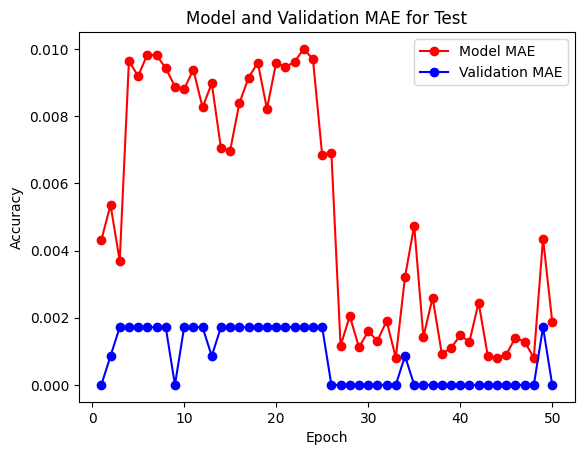

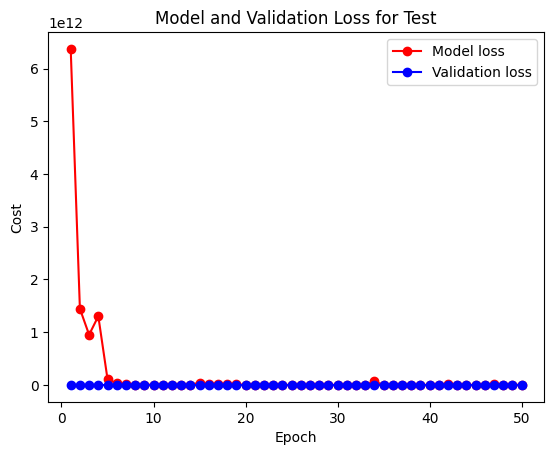

In [127]:
plot_acc_and_loss(model.history, "Test")

In [128]:
print(model(X_train[:10]))
print(Y_train[:10])

tf.Tensor(
[[1.691536 ]
 [1.4141724]
 [1.3477074]
 [1.4011831]
 [1.491477 ]
 [1.4305851]
 [1.399679 ]
 [1.55747  ]
 [1.4500705]
 [1.3385046]], shape=(10, 1), dtype=float32)
[[0.33702801]
 [0.37184451]
 [0.17258584]
 [0.59235678]
 [0.4214214 ]
 [0.17013628]
 [0.06935126]
 [0.09783767]
 [0.05891734]
 [0.30816471]]
